# Libs

In [32]:
import pandas as pd
import numpy as np
from numpy import linalg as LA
import re

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csgraph

from wordcloud import WordCloud
import math

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, SpectralClustering, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import MultiLabelBinarizer, Normalizer
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics.pairwise import euclidean_distances

# 1. Pré-processamento dos dados

In [2]:
## Lendo e exibindo o dataset
df_dataset = pd.read_csv('steam_games.csv', decimal='.')
df_dataset

,appid,name,genres,description,short_description,release_date,positive_ratings,negative_ratings,average_playtime,price
0,10,Counter-Strike,Action,Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...,2000-11-01,124534,3339,17612,7.19
1,20,Team Fortress Classic,Action,One of the most popular online action games of...,One of the most popular online action games of...,1999-04-01,3318,633,277,3.99
2,30,Day of Defeat,Action,Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...,2003-05-01,3416,398,187,3.99
3,40,Deathmatch Classic,Action,Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...,2001-06-01,1273,267,258,3.99
4,50,Half-Life: Opposing Force,Action,Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...,1999-11-01,5250,288,624,3.99
...,...,...,...,...,...,...,...,...,...,...
27068,1065230,Room of Pandora,Adventure;Casual;Indie,"<img src=""https://steamcdn-a.akamaihd.net/stea...",The Room of Pandora is a third-person interact...,2019-04-24,3,0,0,2.09
27069,1065570,Cyber Gun,Action;Adventure;Indie,Have you ever been so lonely that no one but y...,Cyber Gun is a hardcore first-person shooter w...,2019-04-23,8,1,0,1.69
27070,1065650,Super Star Blast,Action;Casual;Indie,<strong>Super Star Blast </strong>is a space b...,Super Star Blast is a space based game with ch...,2019-04-24,0,1,0,3.99
27071,1066700,New Yankee 7: Deer Hunters,Adventure;Casual;Indie,Pursue a snow-white deer through an enchanted ...,Pursue a snow-white deer through an enchanted ...,2019-04-17,2,0,0,5.19


- Como os jogos podem pertencer a mais de um gênero e nesses casos estão separados por ";" converti para listas com o objetivo de facilitar a manipulação

In [3]:
## Removendo colunas desnecessárias
df_dataset.drop(columns=['appid', 'release_date', 'positive_ratings', 'negative_ratings', 'average_playtime', 'price'], inplace=True, errors='ignore')
## Convertendo a coluna de gêneros em listas
df_dataset['genres'] = df_dataset['genres'].str.split(';')
df_dataset

,name,genres,description,short_description
0,Counter-Strike,[Action],Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...
1,Team Fortress Classic,[Action],One of the most popular online action games of...,One of the most popular online action games of...
2,Day of Defeat,[Action],Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...
3,Deathmatch Classic,[Action],Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...
4,Half-Life: Opposing Force,[Action],Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...
...,...,...,...,...
27068,Room of Pandora,"[Adventure, Casual, Indie]","<img src=""https://steamcdn-a.akamaihd.net/stea...",The Room of Pandora is a third-person interact...
27069,Cyber Gun,"[Action, Adventure, Indie]",Have you ever been so lonely that no one but y...,Cyber Gun is a hardcore first-person shooter w...
27070,Super Star Blast,"[Action, Casual, Indie]",<strong>Super Star Blast </strong>is a space b...,Super Star Blast is a space based game with ch...
27071,New Yankee 7: Deer Hunters,"[Adventure, Casual, Indie]",Pursue a snow-white deer through an enchanted ...,Pursue a snow-white deer through an enchanted ...


In [4]:
## Analisando a distribuição dos gêneros
count_generos = df_dataset['genres'].explode().value_counts()
count_generos_percentual = df_dataset['genres'].explode().value_counts(normalize=True) * 100
df_generos = pd.DataFrame({
    'Gênero': count_generos.index,
    'Absoluto': count_generos.values,
    'Percentual (%)': count_generos_percentual.values
})
df_generos['Percentual (%)'] = df_generos['Percentual (%)'].round(2)
df_generos

,Gênero,Absoluto,Percentual (%)
0,Indie,19421,25.75
1,Action,11903,15.78
2,Casual,10210,13.54
3,Adventure,10032,13.30
4,Strategy,5247,6.96
5,Simulation,5194,6.89
6,RPG,4311,5.72
7,Early Access,2954,3.92
8,Free to Play,1704,2.26
9,Sports,1322,1.75


-  Gêneros com poucas ocorrências frente ao tamanho do dataset foram removidos e os jogos associados somente a um desses gêneros não foram considerados na análise

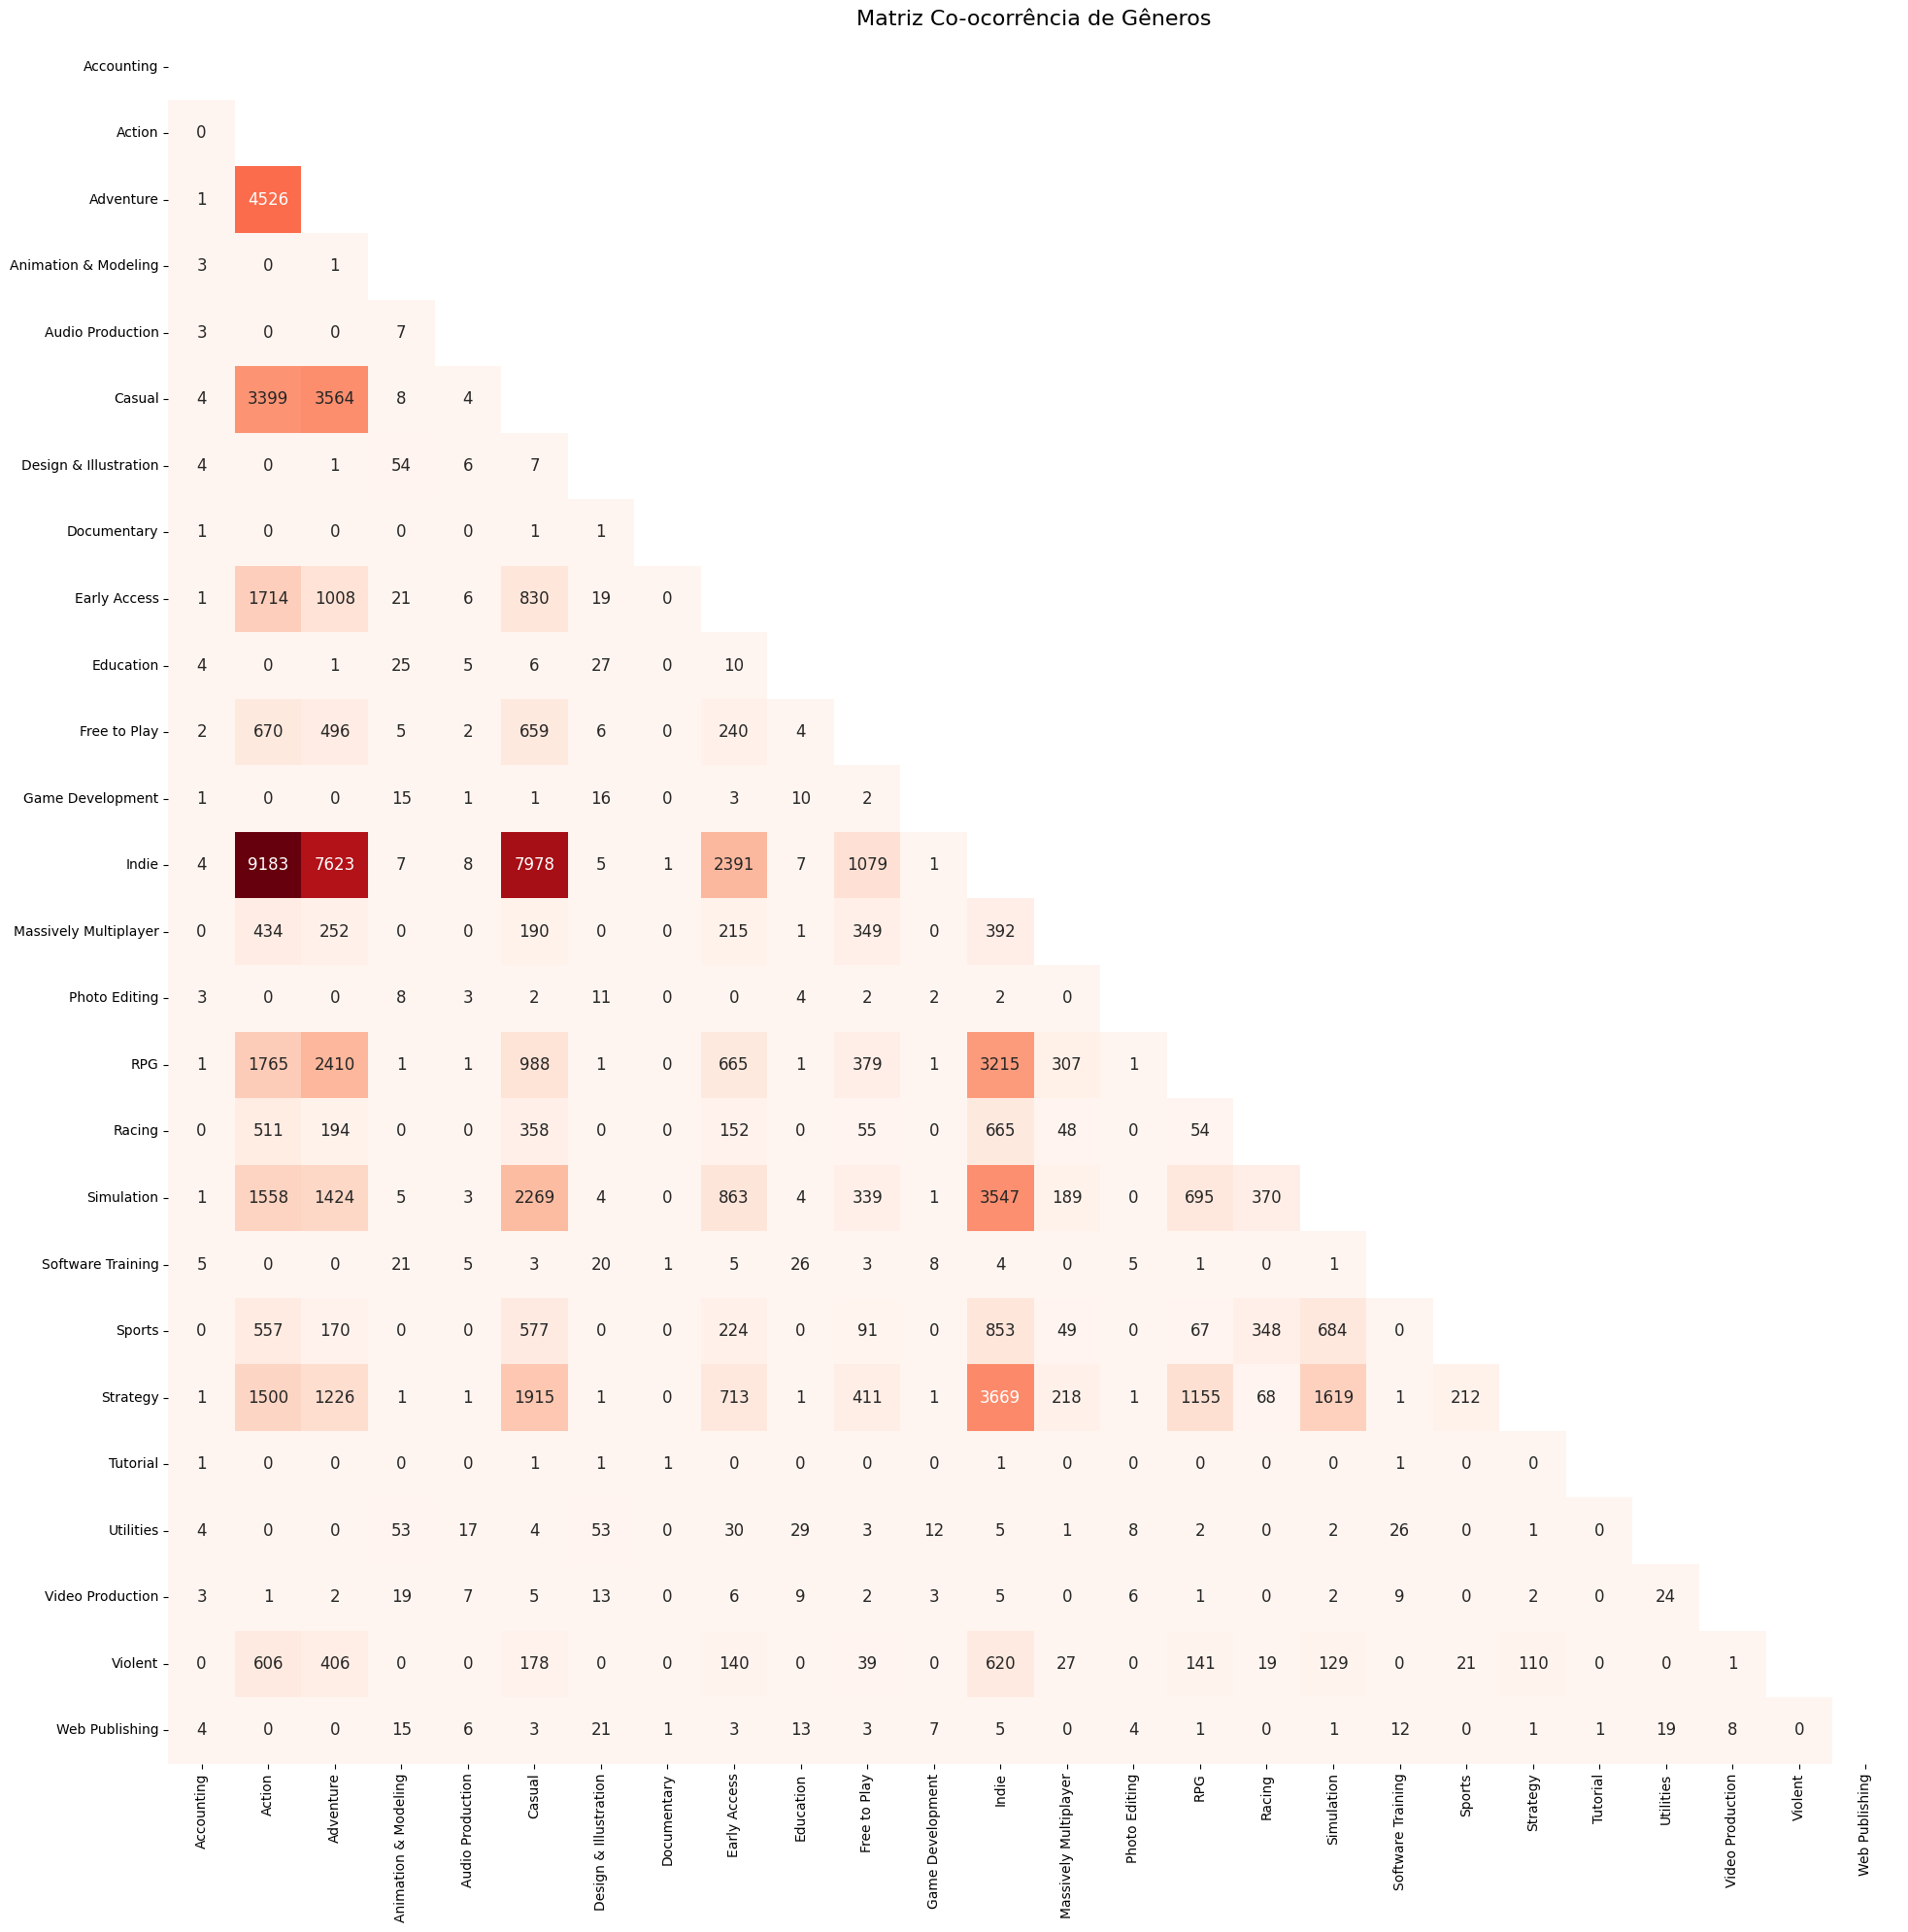

In [5]:
## Plotando a matriz de co-ocorrência de gêneros
mlb = MultiLabelBinarizer()
genre_matrix = pd.DataFrame(mlb.fit_transform(df_dataset['genres']), columns=mlb.classes_)
coocc_matrix = genre_matrix.T.dot(genre_matrix)

mask = np.triu(np.ones_like(coocc_matrix, dtype=bool), k=0)
plt.figure(figsize=(25, 20)) 
sns.heatmap(
    coocc_matrix, 
    mask=mask, 
    annot=True, 
    fmt='d',
    cmap='Reds', 
    cbar=False,
    square=True,
    annot_kws={"size": 12} 
)

plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10, rotation=0)

plt.title('Matriz Co-ocorrência de Gêneros', fontsize=16)
plt.tight_layout()
plt.show()

- A partir da matriz de co-ocorrência dos gêneros é possível perceber que o gênero Indie aparece junto com alguns outros gêneros como Action, Adventure, Casual, Strategy, Simulation e RPG

In [6]:
## Removendo gêneros pouco representativos
LIMITE_OCORRENCIA= 800  # Gêneros com menos de 800 ocorrências serão removidos

contagem_total = df_dataset['genres'].explode().value_counts()

generos_raros = set(contagem_total[contagem_total < LIMITE_OCORRENCIA].index)
print(f"Total de gêneros únicos marcados como pouco representativos: {len(generos_raros)}")

def limpar_generos_raros(lista_generos):
    return [g for g in lista_generos if g not in generos_raros]

nao_generos = {'Free to Play', 'Early Access'}
def limpar_nao_generos(lista_generos):
    return [g for g in lista_generos if g not in nao_generos]

df_dataset['genres'] = df_dataset['genres'].apply(limpar_generos_raros)
df_dataset['genres'] = df_dataset['genres'].apply(limpar_nao_generos)

linhas_antes = len(df_dataset)
df_dataset = df_dataset[df_dataset['genres'].map(len) > 0].copy()
linhas_depois = len(df_dataset)

df_dataset.reset_index(drop=True, inplace=True)

print(f"Linhas removidas (jogos sem gêneros representativos): {linhas_antes - linhas_depois}")
print(f"Novo tamanho do dataset: {linhas_depois}")

df_dataset

Total de gêneros únicos marcados como pouco representativos: 14
Linhas removidas (jogos sem gêneros representativos): 246
Novo tamanho do dataset: 26827


,name,genres,description,short_description
0,Counter-Strike,[Action],Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...
1,Team Fortress Classic,[Action],One of the most popular online action games of...,One of the most popular online action games of...
2,Day of Defeat,[Action],Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...
3,Deathmatch Classic,[Action],Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...
4,Half-Life: Opposing Force,[Action],Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...
...,...,...,...,...
26822,Room of Pandora,"[Adventure, Casual, Indie]","<img src=""https://steamcdn-a.akamaihd.net/stea...",The Room of Pandora is a third-person interact...
26823,Cyber Gun,"[Action, Adventure, Indie]",Have you ever been so lonely that no one but y...,Cyber Gun is a hardcore first-person shooter w...
26824,Super Star Blast,"[Action, Casual, Indie]",<strong>Super Star Blast </strong>is a space b...,Super Star Blast is a space based game with ch...
26825,New Yankee 7: Deer Hunters,"[Adventure, Casual, Indie]",Pursue a snow-white deer through an enchanted ...,Pursue a snow-white deer through an enchanted ...


In [7]:
## Analisando a distribuição dos gêneros após limpeza
count_generos = df_dataset['genres'].explode().value_counts()
count_generos_percentual = df_dataset['genres'].explode().value_counts(normalize=True) * 100
df_generos = pd.DataFrame({
    'Gênero': count_generos.index,
    'Absoluto': count_generos.values,
    'Percentual (%)': count_generos_percentual.values
})
df_generos['Percentual (%)'] = df_generos['Percentual (%)'].round(2)
df_generos

,Gênero,Absoluto,Percentual (%)
0,Indie,19421,27.94
1,Action,11903,17.12
2,Casual,10210,14.69
3,Adventure,10032,14.43
4,Strategy,5247,7.55
5,Simulation,5194,7.47
6,RPG,4311,6.20
7,Sports,1322,1.90
8,Racing,1024,1.47
9,Violent,843,1.21


- Nem todo título de jogo carrega palavras que ajudam a diferenciar ou definir seu gênero por isso optei por não utilizar junto com a descrição
- Percebi que a descrição curta já carrega muitas informações relevantes e assim optei por utilizar ela com objetivo de reduzir ruído para o TF-IDF.
- Adicionei palavras comuns ao universo de jogos como stopwords para evitar que se destacassem no TF-IDF

In [8]:
## Removendo caracteres especiais, stopwords e aplicando lematização
stop_words = set(stopwords.words('english'))
## Além das stopwords padrão, adicionando stopwords específicas do domínio de jogos
domain_stopwords = {
    # Termos genéricos de Jogos
    'game', 'play', 'player', 'steam', 'feature', 'back', 'experience', 'world', 'new', 'best', 'use', 'way', 'go', 'online', 'popular','gameplay', 'first',
    
    # Termos de comercialização dos jogos
    'free', 'edition', 'version', 'available', 'classic', 'original', 'pack', 'dlc', 
    'soundtrack', 'access', 'early', 'development', 'community', 'support', 'content', 
    'include', 'includes', 'great', 'unique', 'award', 'winning', 'fun', 'enjoy', 'real',
    
    # Termos mais técnicos e de plataforma
    'mode', 'system', 'level', 'control', 'controller', 'graphics', 'visual', 'audio', 
    'environment', 'mechanic', 'design', 'engine', 'screen', 'keyboard', 'mouse', 'pc',
    
    # Termos genéricos para vários gêneros
    'character', 'story', 'life', 'way', 'time', 'make', 'take', 'get', 'help', 'find', 
    'challenge', 'skill', 'different', 'various', 'many', 'set', 'place', 'like', 'one', 'two'
}
stop_words.update(domain_stopwords)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    tokens = []
    for w in text.split():
        #remove tokens muito curtos
        if len(w) < 3:
            continue
        #remove stopwords
        if w in stop_words:
            continue
        #lematização
        lemma = lemmatizer.lemmatize(w, pos='v')
        if lemma == w:
            lemma = lemmatizer.lemmatize(w)
        tokens.append(lemma)

    return ' '.join(tokens)

df_dataset['clean_text'] = df_dataset['short_description'].apply(clean_text)
df_dataset

,name,genres,description,short_description,clean_text
0,Counter-Strike,[Action],Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...,world number action engage incredibly realisti...
1,Team Fortress Classic,[Action],One of the most popular online action games of...,One of the most popular online action games of...,action game team fortress feature nine class m...
2,Day of Defeat,[Action],Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...,enlist intense brand axis ally teamplay wwii e...
3,Deathmatch Classic,[Action],Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...,fastpaced multiplayer game deathmatch aka dmc ...
4,Half-Life: Opposing Force,[Action],Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...,return black mesa research facility military s...
...,...,...,...,...,...
26822,Room of Pandora,"[Adventure, Casual, Indie]","<img src=""https://steamcdn-a.akamaihd.net/stea...",The Room of Pandora is a third-person interact...,room pandora thirdperson interactive puzzle li...
26823,Cyber Gun,"[Action, Adventure, Indie]",Have you ever been so lonely that no one but y...,Cyber Gun is a hardcore first-person shooter w...,cyber gun hardcore firstperson shooter platfor...
26824,Super Star Blast,"[Action, Casual, Indie]",<strong>Super Star Blast </strong>is a space b...,Super Star Blast is a space based game with ch...,super star blast space base challenge level in...
26825,New Yankee 7: Deer Hunters,"[Adventure, Casual, Indie]",Pursue a snow-white deer through an enchanted ...,Pursue a snow-white deer through an enchanted ...,pursue snowwhite deer enchant forest discover ...


# 2. TF-IDF

In [9]:
tfidf = TfidfVectorizer(
    min_df=10,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words=list(stop_words),
    norm='l2'
)
X_tfidf = tfidf.fit_transform(df_dataset['clean_text'])
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 393161 stored elements and shape (26827, 6149)>

# 3. Redução de dimensionalidade

 - Utilizar o PCA na matrix sparsa gerada é muito caro, por isso foi utilizado o TruncatedSVD que consegue trabalhar com matrizes esparsas
 - O número de componentes foi definido de modo a reter aproximadamente 20% da variância para que menos ruído fosse mantido

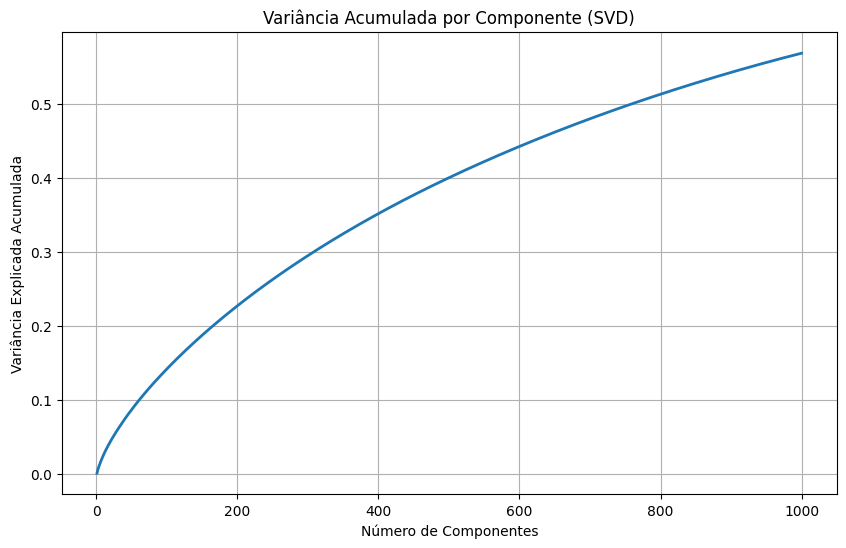

In [10]:
svd_analysis = TruncatedSVD(n_components=1000, random_state=42)
svd_analysis.fit(X_tfidf)

variance_cumsum = np.cumsum(svd_analysis.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 1001), variance_cumsum, linewidth=2)
plt.title('Variância Acumulada por Componente (SVD)')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

- Para dados textuais manter uma alta variância implica em manter muito ruído nos dados (palavras que não diferenciam bem os gêneros), por isso foi escolhido um número de componentes igual a 200 que mantém ~20% da variância dos dados.

In [11]:
svd = TruncatedSVD(n_components=200, random_state=42) 
X_svd = svd.fit_transform(X_tfidf)

print(f"Variância explicada: {svd.explained_variance_ratio_.sum():.2f}")
print(f"Shape final: {X_svd.shape}")

Variância explicada: 0.22
Shape final: (26827, 200)


# 4. Clustering

## Visualização em 2D utilizando t-SNE

### t-SNE

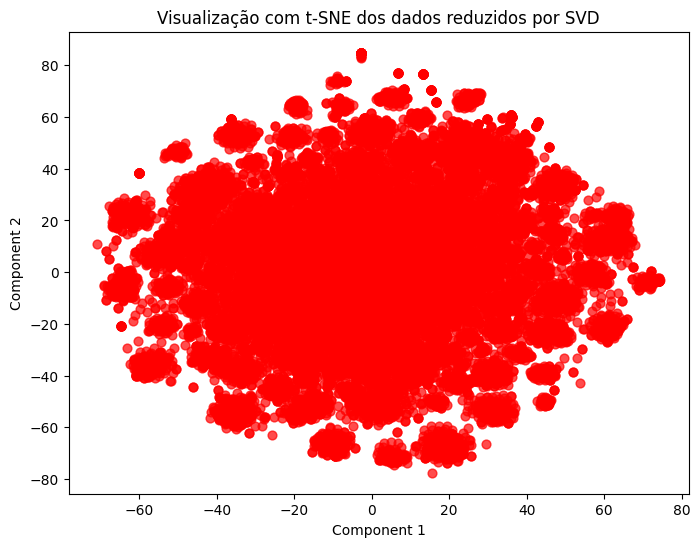

In [12]:
tsne = TSNE(
    n_components=2,
    perplexity=50,
    early_exaggeration=12.0,
    learning_rate='auto',
    max_iter=1000,
    n_iter_without_progress=500,
    min_grad_norm=1e-7,
    metric='euclidean',
    init='pca',
    random_state=42,
    method='barnes_hut',
    angle=0.5,
    verbose=0,
    n_jobs=None
)

X_embedded = tsne.fit_transform(X_svd)
plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s=40, alpha=0.7, c='red')
plt.title("Visualização com t-SNE dos dados reduzidos por SVD")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

- A partir do t-SNE é possível perceber que não há regiões densas e bem separadas, isso ocorre principalmente porque os jogos podem pertecner há diferentes gêneros e também por conta do eventual ruído de palavas (palavras que não ajudam a diferenciar clusters) no TF-IDF

## KMeans

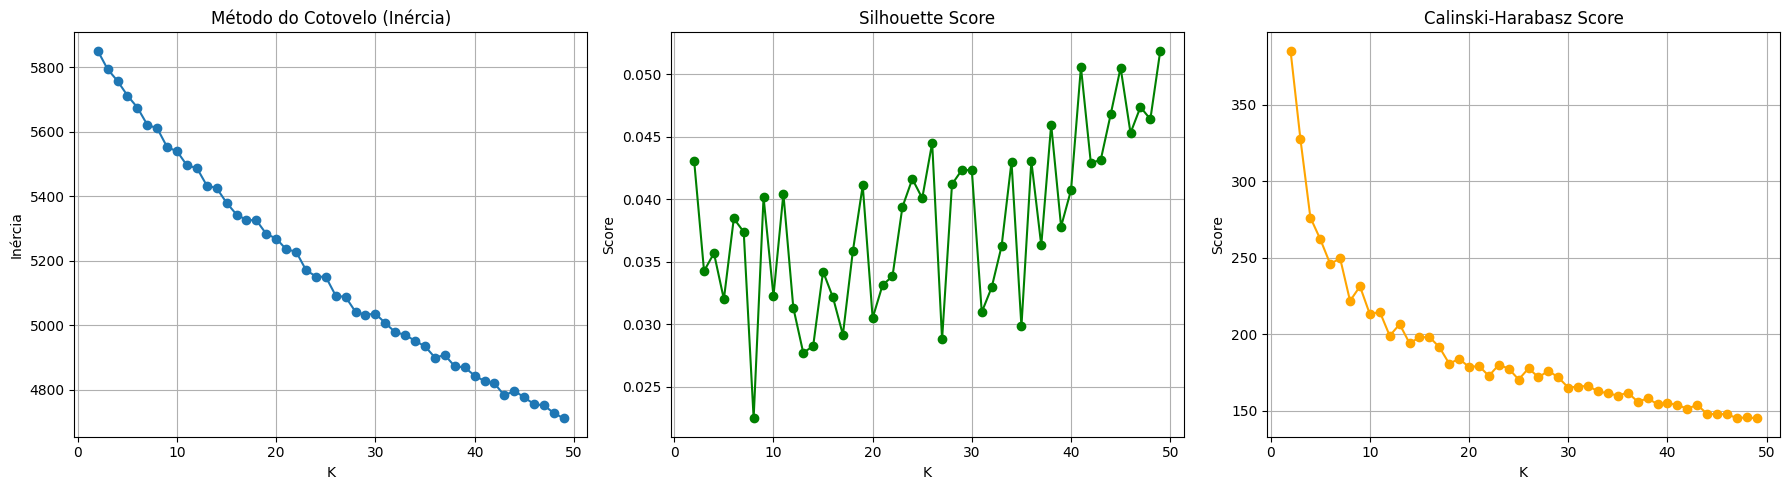

In [13]:
## Aplicando busca para o melhor K usando método do cotovelo, silhouette score e calinski-harabasz
K_range = range(2, 50)

inertia = []
silhouette_scores = []
calinski_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd)
    
    inertia.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(X_svd, labels)
    silhouette_scores.append(silhouette_avg)
    
    ch_score = calinski_harabasz_score(X_svd, labels)
    calinski_scores.append(ch_score)

plt.figure(figsize=(18, 5))

# Gráfico 1: Cotovelo (Inércia)
plt.subplot(1, 3, 1)
plt.plot(K_range, inertia, marker='o')
plt.title('Método do Cotovelo (Inércia)')
plt.xlabel('K')
plt.ylabel('Inércia')
plt.grid(True)

# Gráfico 2: Silhouette Score
plt.subplot(1, 3, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('K')
plt.ylabel('Score')
plt.grid(True)

# Gráfico 3: Calinski-Harabasz
plt.subplot(1, 3, 3)
plt.plot(K_range, calinski_scores, marker='o', color='orange')
plt.title('Calinski-Harabasz Score')
plt.xlabel('K')
plt.ylabel('Score')
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Definindo K baseado no número de gêneros únicos observados
K = 20

# Algoritmo A: K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_svd)

- A escolha do menor número de clusters nesse caso não é trivial, avaliando os gráficos é possível perceber que não há um número claro de clusters para os dados, porém avaliando a curve de inércia a partir de k=20 a curva aparenta um comportamento levemente mais linear e por isso foi escolhido esse número de clusters. O coeficiene de silhueta permanece com valores baixos para todos os K clusters avaliados.

In [15]:
df_dataset['cluster'] = labels_kmeans
df_exploded = df_dataset.explode('genres')

cross_tab_pct = pd.crosstab(df_exploded['cluster'], df_exploded['genres'], normalize='index')
cross_tab_pct = cross_tab_pct * 100

def get_top_genres_per_cluster(cross_tab_pct, top_n=5):
    print(f"{'Cluster':<10} | {'Principais Gêneros (com %)'}")
    print("-" * 60)
    
    for cluster_id in cross_tab_pct.index:
        top_genres = cross_tab_pct.loc[cluster_id].nlargest(top_n)
        genre_str = ", ".join([f"{g} ({v:.1f}%)" for g, v in top_genres.items()])
        print(f"{cluster_id:<10} | {genre_str}")

get_top_genres_per_cluster(cross_tab_pct)

Cluster    | Principais Gêneros (com %)
------------------------------------------------------------
0          | Indie (26.5%), Adventure (19.4%), Action (15.7%), Casual (12.3%), Simulation (7.9%)
1          | Indie (28.2%), Action (27.4%), Casual (12.4%), Strategy (8.2%), Adventure (5.8%)
2          | Strategy (22.7%), Indie (21.9%), Action (19.1%), Simulation (10.0%), Adventure (9.6%)
3          | Indie (29.1%), Casual (19.9%), Adventure (19.7%), RPG (9.1%), Action (8.8%)
4          | Indie (29.2%), Action (28.0%), Adventure (9.6%), Casual (9.5%), RPG (8.9%)
5          | Indie (29.4%), Strategy (28.5%), Action (16.1%), Casual (13.8%), Adventure (3.9%)
6          | Indie (27.2%), Casual (16.6%), Adventure (15.1%), Action (13.7%), Simulation (9.6%)
7          | Indie (25.5%), Adventure (21.7%), Action (19.1%), Casual (15.3%), RPG (8.8%)
8          | Indie (24.5%), Casual (15.0%), Simulation (15.0%), Action (11.5%), Strategy (10.7%)
9          | Simulation (30.2%), Indie (23.0%), Casua

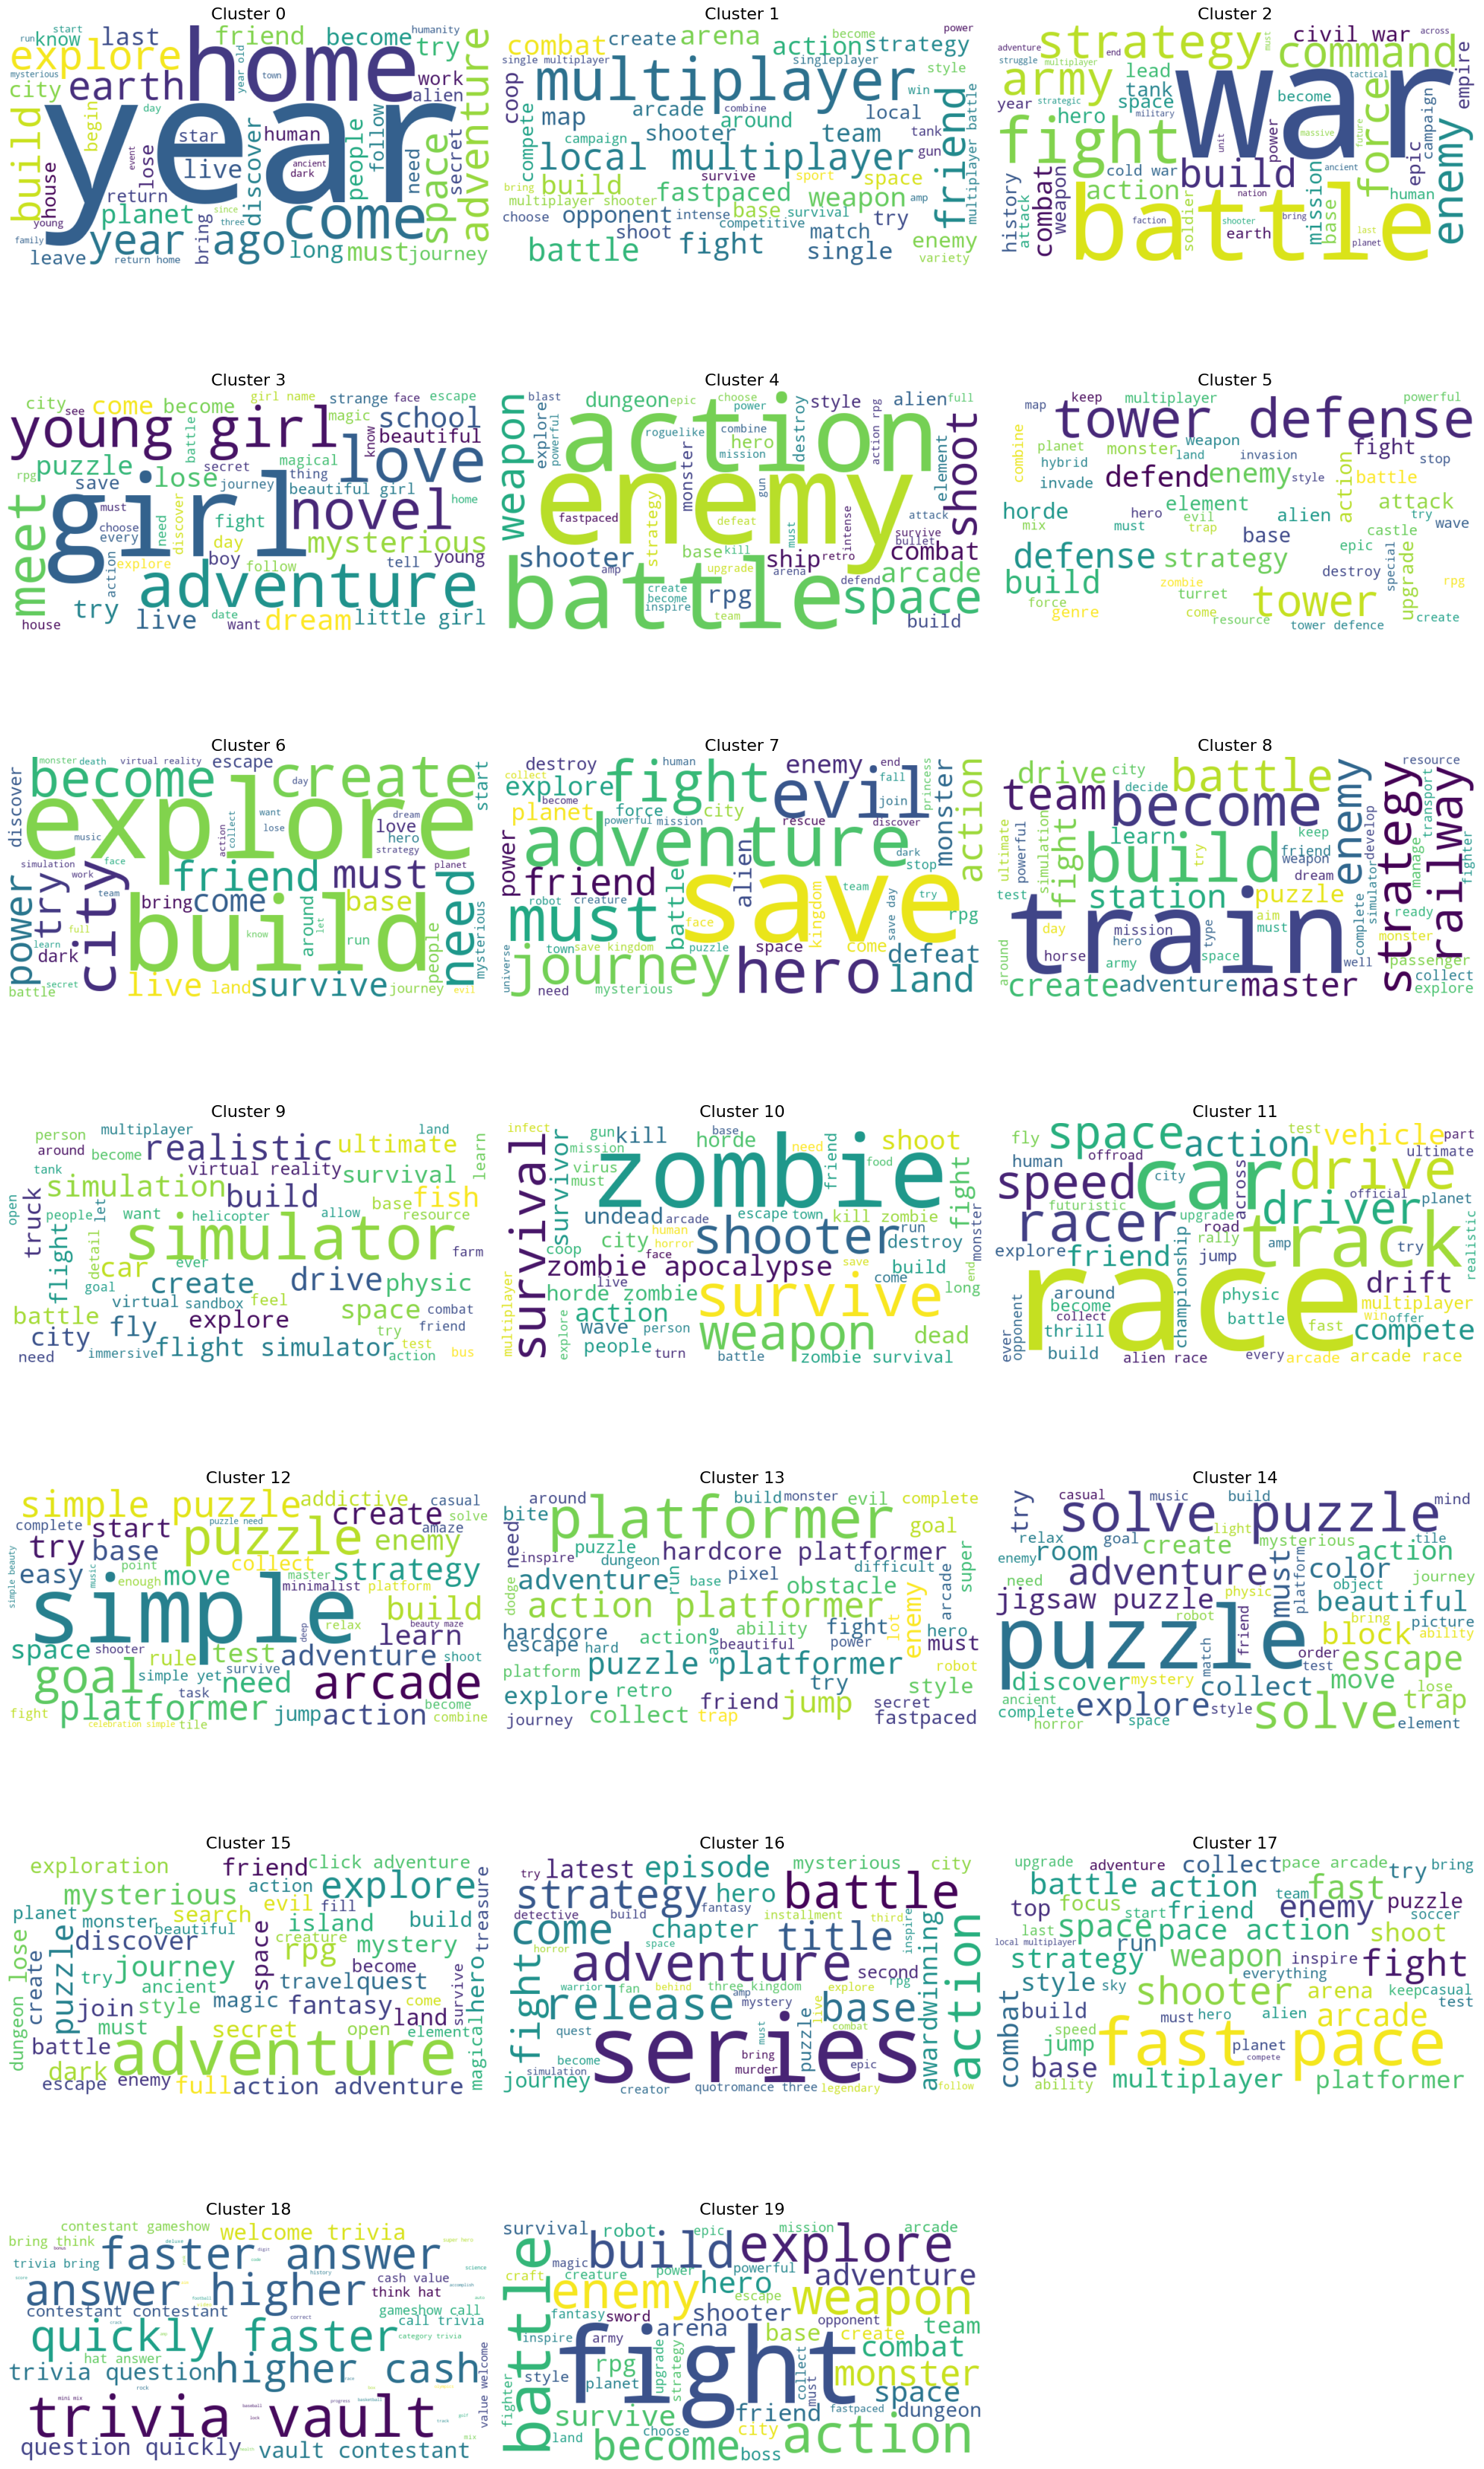

In [16]:
clusters_unicos = sorted(df_dataset['cluster'].unique())
n_clusters = len(clusters_unicos)
n_cols = 3
n_rows = math.ceil(n_clusters / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, cluster_id in enumerate(clusters_unicos):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    text_cluster = " ".join(df_dataset[df_dataset['cluster'] == cluster_id]['clean_text'].astype(str))
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        stopwords=stop_words,
        max_words=50,
        colormap='viridis'
    ).generate(text_cluster)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Cluster {cluster_id}", fontsize=16)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [28]:
def busca_jogos_representativos(model, data_svd, df, n_examples=5):
    distances = model.transform(data_svd)
    
    print(f"{'Cluster':<8} | {'Jogos próximos ao centroide de cada cluster (Nome + Gêneros)'}")
    print("-" * 120)
    
    for i in range(model.n_clusters):
        closest_indices = np.argsort(distances[:, i])[:n_examples]
        subset = df.iloc[closest_indices]
        games_info = [f"{row['name']} {row['genres']}" for _, row in subset.iterrows()]
        games_str = " || ".join(games_info)
        print(f"{i:<8} | {games_str}")

busca_jogos_representativos(kmeans, X_svd, df_dataset, n_examples=3)

Cluster  | Jogos próximos ao centroide de cada cluster (Nome + Gêneros)
------------------------------------------------------------------------------------------------------------------------
0        | Tex Murphy: Martian Memorandum ['Adventure'] || Assassin’s Creed® Liberation HD ['Action', 'Adventure'] || Bohemian Killing ['Adventure', 'Indie']
1        | Day of Defeat: Source ['Action'] || CasinoRPG ['Casual', 'Indie', 'RPG', 'Simulation'] || Where's Baby ['Action', 'Casual']
2        | Eve of Destruction - REDUX VIETNAM ['Action', 'Adventure', 'Casual', 'Indie', 'Simulation', 'Strategy'] || Soup: the Game ['Action', 'Indie', 'Simulation', 'Strategy'] || Cannonfire Concerto ['Adventure', 'Indie', 'RPG']
3        | Ladykiller in a Bind ['Indie'] || Shan Gui 2: Chapter 1 · 山桂贰：第一章 ['Adventure', 'Casual', 'Indie'] || Truth: Disorder III — Gemini / 真実：障害III - 双子座 ['Indie']
4        | BERSERK and the Band of the Hawk ['Violent', 'Action'] || Siam Twinstick ['Indie'] || Surface: The Pan

## Spectral Clustering

In [17]:
# Construindo a matriz de adjacências do grafo de vizinhos mais próximos.
G = kneighbors_graph(X_svd, n_neighbors = 10, include_self = True)
A = 0.5 * (G + G.T)

# Construindo a Laplaciana Normalizada
L = csgraph.laplacian(A, normed = True).todense()

# Obtendo os autovalores da Laplaciana Normalizada
values, _ = LA.eigh(L)

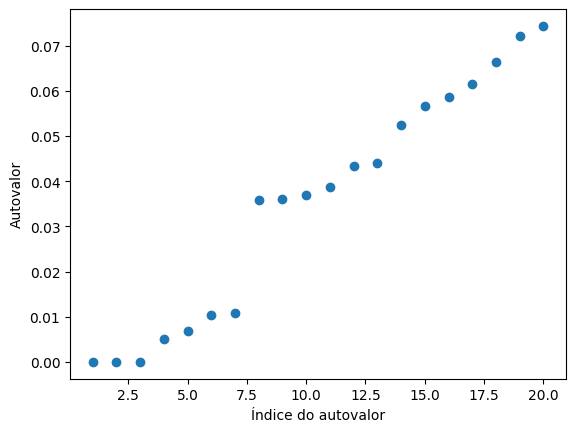

In [18]:
# Plotando os valores dos 'gaps' e escolhendo um k adequado.
plt.scatter([i for i in range(1, 21)], values[:20])
plt.xlabel('Índice do autovalor')
plt.ylabel('Autovalor');

In [19]:
## Verificando maior gap entre os autovalores
gaps = np.diff(values)
K_spectral = np.argmax(gaps[:20]) + 1
print(f"O maior gap entre autovalores ocorre no índice: {K_spectral}")

O maior gap entre autovalores ocorre no índice: 7


In [20]:
spectral = SpectralClustering(n_clusters = 7, affinity = 'nearest_neighbors', n_neighbors = 10)
labels_spectral = spectral.fit_predict(X_svd)

/Users/falcone/Desktop/Projects/CD-2025-2/venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [21]:
df_dataset['cluster_spectral'] = labels_spectral
df_exploded = df_dataset.explode('genres')

cross_tab_pct = pd.crosstab(df_exploded['cluster_spectral'], df_exploded['genres'], normalize='index')
cross_tab_pct = cross_tab_pct * 100

def get_top_genres_per_cluster(cross_tab_pct, top_n=5):
    print(f"{'Cluster':<10} | {'Principais Gêneros (com %)'}")
    print("-" * 60)
    
    for cluster_id in cross_tab_pct.index:
        top_genres = cross_tab_pct.loc[cluster_id].nlargest(top_n)
        genre_str = ", ".join([f"{g} ({v:.1f}%)" for g, v in top_genres.items()])
        print(f"{cluster_id:<10} | {genre_str}")

get_top_genres_per_cluster(cross_tab_pct)

Cluster    | Principais Gêneros (com %)
------------------------------------------------------------
0          | Indie (28.0%), Action (17.2%), Casual (14.6%), Adventure (14.5%), Strategy (7.5%)
1          | Casual (26.7%), Simulation (22.1%), Action (21.4%), Strategy (17.6%), Indie (12.2%)
2          | Strategy (56.0%), Indie (16.0%), Simulation (16.0%), Casual (8.0%), RPG (4.0%)
3          | Casual (34.4%), Indie (31.2%), Adventure (18.8%), Action (9.4%), Racing (6.2%)
4          | Casual (50.0%), Indie (50.0%), Action (0.0%), Adventure (0.0%), RPG (0.0%)
5          | Casual (50.0%), Indie (50.0%), Action (0.0%), Adventure (0.0%), RPG (0.0%)
6          | Casual (33.3%), Indie (33.3%), Strategy (33.3%), Action (0.0%), Adventure (0.0%)


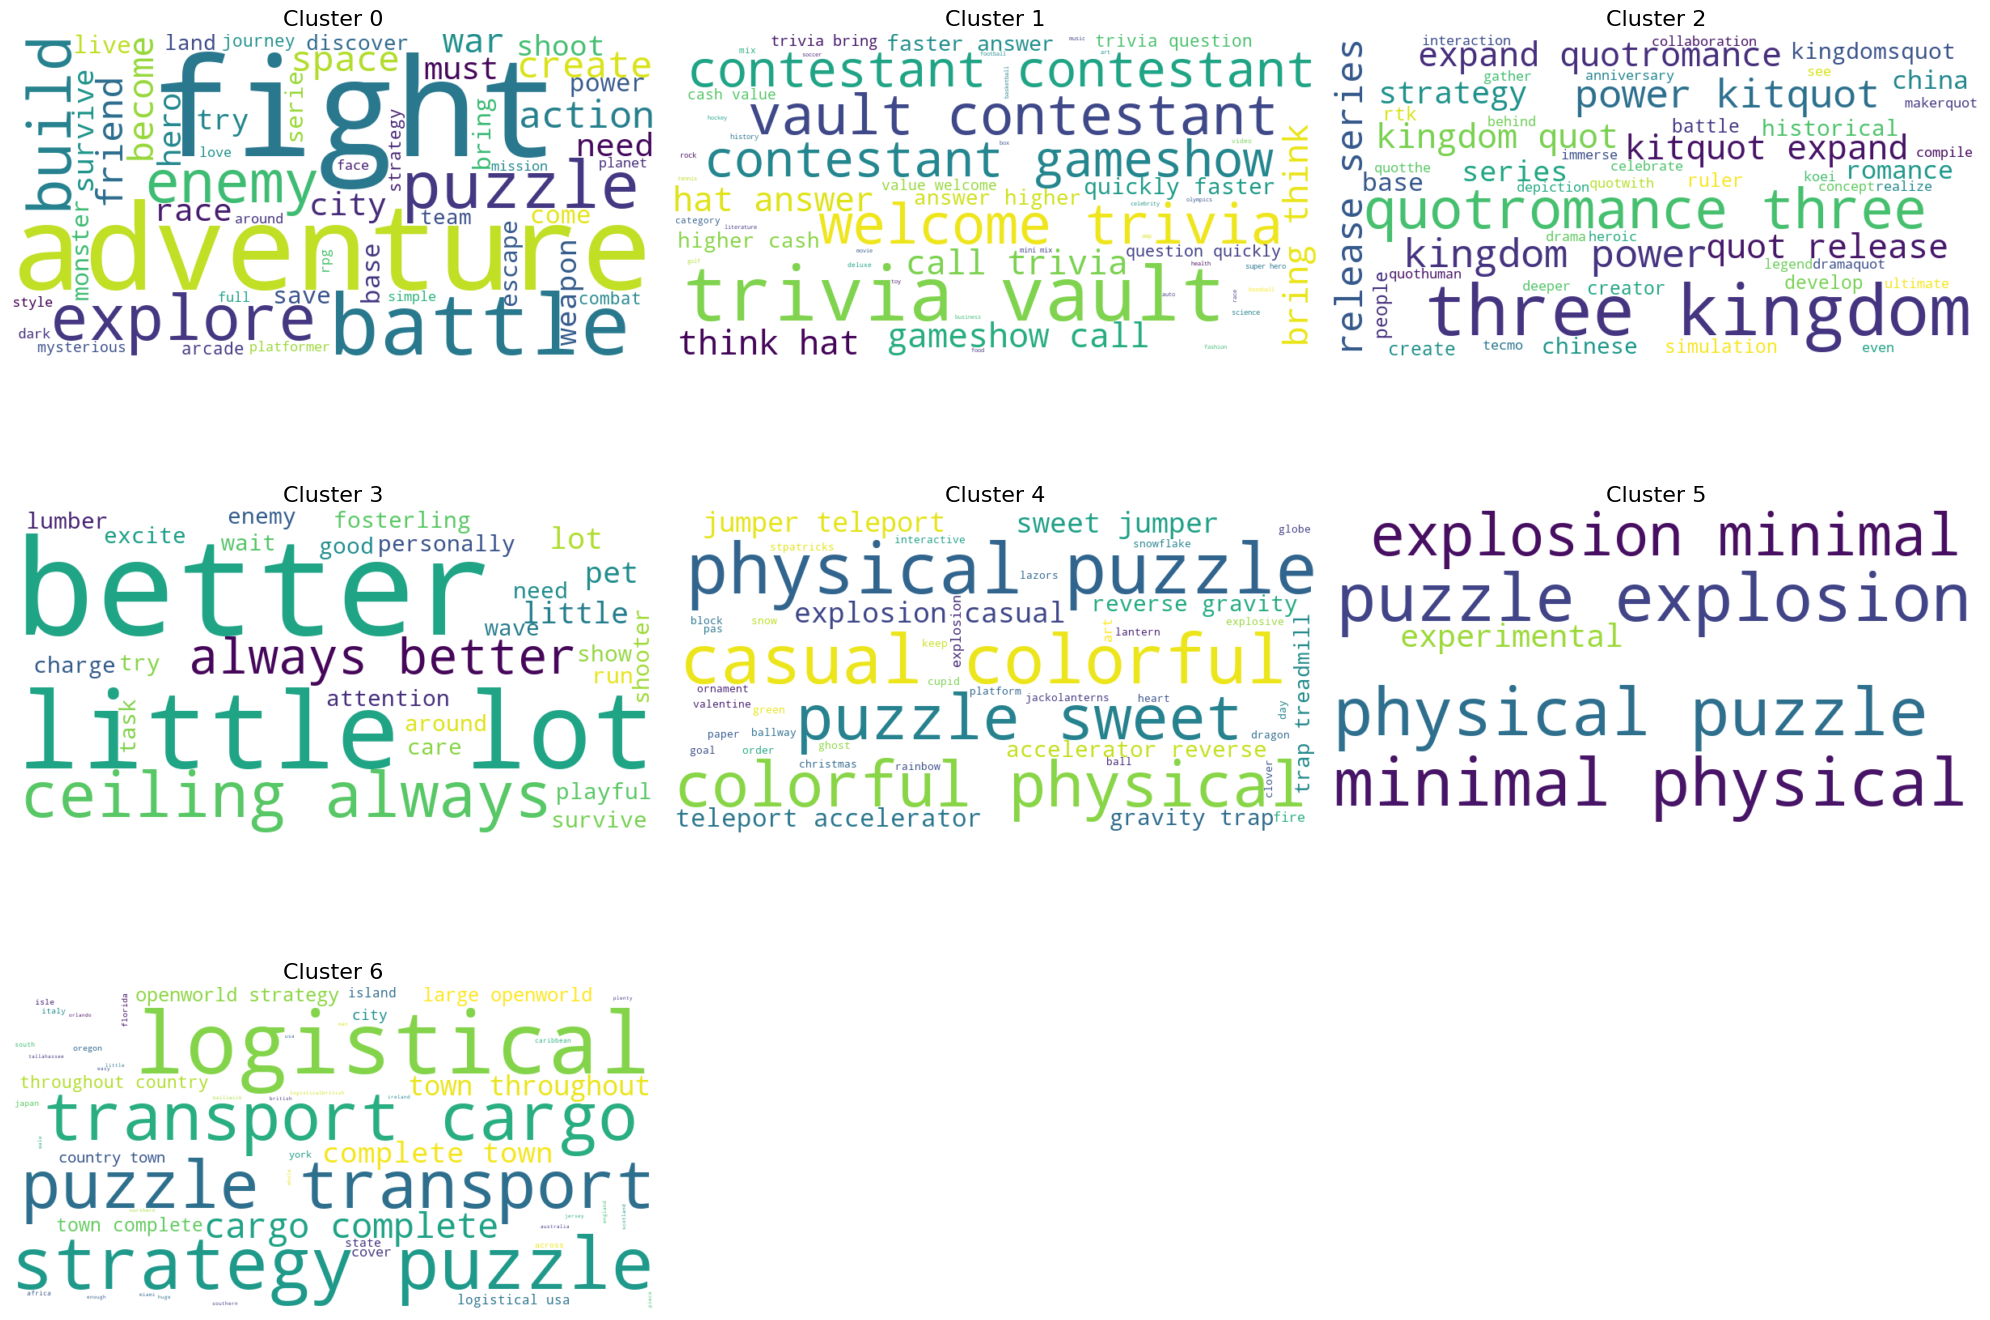

In [23]:
clusters_unicos = sorted(df_dataset['cluster_spectral'].unique())
n_clusters = len(clusters_unicos)
n_cols = 3
n_rows = math.ceil(n_clusters / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, cluster_id in enumerate(clusters_unicos):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    text_cluster = " ".join(df_dataset[df_dataset['cluster_spectral'] == cluster_id]['clean_text'].astype(str))
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        stopwords=stop_words,
        max_words=50,
        colormap='viridis'
    ).generate(text_cluster)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f"Cluster {cluster_id}", fontsize=16)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [33]:
def busca_jogos_representativos_spectral(labels, data_svd, df, n_examples=5):
    unique_labels = sorted(np.unique(labels))
    
    print(f"{'Cluster':<8} | {'Jogos próximos ao centroide calculado (Nome + Gêneros)'}")
    print("-" * 120)
    
    for i in unique_labels:
        indices_do_cluster = np.where(labels == i)[0]
        
        pontos_do_cluster = data_svd[indices_do_cluster]
        
        centroide = pontos_do_cluster.mean(axis=0).reshape(1, -1)
        
        distancias = euclidean_distances(pontos_do_cluster, centroide).flatten()
        
        indices_locais_mais_proximos = np.argsort(distancias)[:n_examples]
        indices_globais = indices_do_cluster[indices_locais_mais_proximos]
        
        subset = df.iloc[indices_globais]
        games_info = [f"{row['name']} {row['genres']}" for _, row in subset.iterrows()]
        games_str = " || ".join(games_info)
        
        print(f"{i:<8} | {games_str}")

busca_jogos_representativos_spectral(spectral.labels_, X_svd, df_dataset, n_examples=3)

Cluster  | Jogos próximos ao centroide calculado (Nome + Gêneros)
------------------------------------------------------------------------------------------------------------------------
0        | President Erect VR ['Casual', 'Indie'] || Surface: The Pantheon Collector's Edition ['Adventure', 'Casual'] || 心之檻 ['Casual', 'Indie', 'RPG']
1        | Trivia Vault: Celebrity Trivia ['Action', 'Casual', 'Simulation', 'Strategy'] || Trivia Vault: Hockey Trivia ['Action', 'Casual', 'Indie', 'Simulation'] || Trivia Vault: 1980's Trivia ['Casual', 'Indie', 'Simulation', 'Strategy']
2        | Romance of the Three Kingdoms　VI with Power Up Kit / 三國志VI with パワーアップキット ['Strategy'] || Romance of the Three Kingdoms X with Power Up Kit / 三國志X with パワーアップキット ['Strategy'] || Romance of the Three Kingdoms 12 with Power Up Kit / 三國志12 with パワーアップキット ['Strategy']
3        | Slippingcers ['Adventure', 'Casual', 'Indie'] || Gravitycers ['Adventure', 'Casual', 'Indie', 'Racing'] || Rocketcers ['Adventure', 

# Conclusões

Avaliando a escolha do número ideal de clusters no kmeans foi possível perceber que o Silhouette Score sobe conforme o $K$ aumenta indicando que os clusters não são bem separados e há grande sobreposição entre eles confirmado pelo score máximo (~0.06) evidenciando que os jogos compartilham muitio vocabulário.

O K-Means conseguiu capturar bem tópicos semânticos, apesar da mistura de gêneros nos rótulos, ele identificou clusters claros de 
- Corrida (Cluster 11 - "drift", "speed", "race")
- Simulação de Voo/Espaço (Cluster 9 - "flight", "simulator") 
- Zumbis (Cluster 10 - "zombie", "survival").

O gênero "Indie" domina quase todos os clusters (aparece com >20% em vários). Isso mostra que "Indie" não é exatamente um gênero, mas um rótulo de mercado que está presente em grande parte dos jogos.

Já o Spectral Clustering se comportou focando na estrutura do grafo de vizinhos agrupando jogos que são praticamente idênticos.
- Cluster 1: "Trivia Vault" (vários jogos com mesmo nome e descrição).
- Cluster 2: "Romance of the Three Kingdoms" (série específica).
- Cluster 5: "Zup!" (jogos de puzzle minimalistas idênticos) .

O algoritmo Spectral encontrou "ilhas" de jogos desconectados do resto (séries repetitivas), em vez de gêneros amplos.

Os rótulos "Indie", "Action", "Casual" e "Adventure" aparecem distribuídos em quase todos os clusters formados. Esses rótulos não descrevem o conteúdo do jogo, apenas seu escopo ou orçamento. Um "Action Indie" pode ser um jogo de tiro (Cluster 10) ou um plataforma (Cluster 13).

O Cluster 10 (KMeans) agrupou jogos descritos como "Zombie", "Survival", "Apocalypse". O modelo descobriu o gênero "Survival Horror" sozinho, mesmo que os jogos estivessem rotulados apenas como "Action" ou "Indie".

A métrica Silhouette continua subindo linearmente até $K=50$ e isso sugere que o mercado de jogos é composto por centenas de micro-comunidades. Tentar forçar os dados em 7 ou 20 clusters mistura muito nichos distintos.